# Simplest GPT Implementation from Scratch

### In this notebook, I'am going to build the simplest implementation of a GPT-style Transformer (Decoder-Only architecture) using PyTorch and train it on the Tiny Shakespeare dataset.

The goal of this notebook is to understand:
- How GPT works internally
- Token embeddings and positional embeddings
- Multi-Head Self-Attention
- Feed-Forward Networks
- Transformer blocks
- Autoregressive text generation

This notebook focuses on learning the core concepts instead of building a production-level LLM.

In [1]:
import os, time
if not os.path.exists("/content/input.txt"):
  !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-05-19 10:41:45--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.02s   

2026-05-19 10:41:46 (54.4 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset

Loading the Tiny Shakespeare dataset and converting text into character-level tokens.

Steps covered:
- Reading text data
- Building vocabulary
- Character-to-index mapping
- Encoding and decoding text
- Creating training and validation batches


In [3]:
input_file_path = "/content/input.txt"

with open(input_file_path, "r") as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

# Creating character-to-index and index-to-character mappings
input_mapper = {ch: i for i, ch in enumerate(chars)}
output_mapper = {i: ch for i, ch in enumerate(chars)}

# Encoder-Decoder
encoder = lambda s: [input_mapper[c] for c in s]
# Encoder: takes a string and converts it into a list of integers

decoder = lambda l: "".join(output_mapper[i] for i in l)
# Decoder: takes a list of integers and converts it back into a string

print("Total length of data:", len(text))
print("Total characters:", "".join(chars))
print("\nVocab size:", vocab_size)

print("Encoding:", encoder("hi everyone"))
print("Decoding:", decoder(encoder("hi everyone")))

Total length of data: 1115394
Total characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Vocab size: 65
Encoding: [46, 47, 1, 43, 60, 43, 56, 63, 53, 52, 43]
Decoding: hi everyone


In [4]:
data = torch.tensor(encoder(text), dtype=torch.long)  # Converting encoded text into a tensor

n = int(0.9 * len(data))  # 90% of the data will be used for training

train_data = data[:n]  # Training dataset
val_data = data[n:]    # Validation dataset

def get_batch(split):
    data = train_data if split == "train" else val_data

    # Random starting indices for batch samples
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Input sequences
    x = torch.stack([data[i : i + block_size] for i in ix]).to(device)

    # Target sequences shifted by one position
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix]).to(device)

    return x, y

## Transformer Architecture

Building a Decoder-Only Transformer architecture from scratch.

Components covered:
- Input Embeddings
- Positional Embeddings
- Multi-Head Self-Attention (Masked Attention)
- Feed-Forward Network (FFN)
- Residual Connections
- Layer Normalization
- Transformer Blocks
- GPT Language Model

In [5]:
# Input Embedding Block
class TransformerEmbedding(torch.nn.Module):
    def __init__(self, vocab_size, emb_d, block_size):
        super().__init__()

        # Token embeddings: (B, T) -> (B, T, D)
        self.token_embedding_table = torch.nn.Embedding(vocab_size, emb_d)

        # Positional embeddings: (T) -> (T, D)
        self.position_embedding_table = torch.nn.Embedding(block_size, emb_d)

    def forward(self, x):
        B, T = x.shape

        tok_emb = self.token_embedding_table(x)  # Token embeddings
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=x.device)
        )  # Positional embeddings

        return tok_emb + pos_emb

In [6]:
# Multi-Head Attention Block

class MultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_d, num_heads, block_size, dropout=0.2):
        super().__init__()

        assert emb_d % num_heads == 0

        self.emb_d = emb_d
        self.num_heads = num_heads
        self.head_size = emb_d // num_heads

        # Query, Key, Value projections
        self.query = torch.nn.Linear(emb_d, emb_d, bias=False)
        self.key = torch.nn.Linear(emb_d, emb_d, bias=False)
        self.value = torch.nn.Linear(emb_d, emb_d, bias=False)

        # Dropout layers
        self.attn_dropout = torch.nn.Dropout(dropout)
        self.proj_dropout = torch.nn.Dropout(dropout)

        # Output projection
        self.out_proj = torch.nn.Linear(emb_d, emb_d)

        # Causal mask
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(block_size, block_size), diagonal=1).bool()
        )

    def forward(self, x):
        B, T, D = x.shape

        # Query, Key, Value projections
        q = self.query(x)  # (B, T, D)
        k = self.key(x)    # (B, T, D)
        v = self.value(x)  # (B, T, D)

        # Split embeddings into multiple heads
        q = q.view(B, T, self.num_heads, self.head_size)  # (B, T, H, HS)
        k = k.view(B, T, self.num_heads, self.head_size)  # (B, T, H, HS)
        v = v.view(B, T, self.num_heads, self.head_size)  # (B, T, H, HS)

        # Move head dimension before sequence dimension
        q = q.transpose(1, 2)  # (B, H, T, HS)
        k = k.transpose(1, 2)  # (B, H, T, HS)
        v = v.transpose(1, 2)  # (B, H, T, HS)

        # Attention scores
        wei = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)  # (B, H, T, T)

        # Apply causal mask
        wei = wei.masked_fill(
            self.mask[:T, :T],
            float('-inf')
        )

        # Attention probabilities
        wei = torch.nn.functional.softmax(wei, dim=-1)

        # Dropout on attention probabilities
        wei = self.attn_dropout(wei)

        # Weighted aggregation
        out = wei @ v  # (B, H, T, HS)

        # Restore original tensor shape
        out = out.transpose(1, 2)  # (B, T, H, HS)
        out = out.contiguous()

        # Merge all attention heads
        out = out.view(B, T, self.emb_d)

        # Output projection
        out = self.out_proj(out)

        # Dropout on output projection
        out = self.proj_dropout(out)

        return out

In [7]:
# Feed-Forward Network (FFN)

class FeedForward(torch.nn.Module):
    def __init__(self, emb_d, dropout=0.2):
        super().__init__()

        self.l1 = torch.nn.Linear(emb_d, emb_d * 4)
        self.gelu = torch.nn.GELU()
        self.dropout = torch.nn.Dropout(dropout)
        self.l2 = torch.nn.Linear(emb_d * 4, emb_d)

    def forward(self, x):
        out = self.l1(x)
        out = self.gelu(out)

        # Dropout after activation
        out = self.dropout(out)

        out = self.l2(out)

        # Dropout after output projection
        out = self.dropout(out)

        return out

In [8]:
# Transformer Block (MHA + FFN)

class Block(torch.nn.Module):
    def __init__(self, emb_d, num_heads, block_size, dropout):
        super().__init__()

        self.sa = MultiHeadAttention(emb_d, num_heads, block_size, dropout)
        self.ffwd = FeedForward(emb_d, dropout)

        self.ln1 = torch.nn.LayerNorm(emb_d)
        self.ln2 = torch.nn.LayerNorm(emb_d)

    def forward(self, x):

        # Self-attention sub-layer with residual connection
        x = x + self.sa(self.ln1(x))

        # Feed-forward sub-layer with residual connection
        x = x + self.ffwd(self.ln2(x))

        return x

In [9]:
# Final GPT Model Architecture

class GPTLanguageModel(torch.nn.Module):
    def __init__(self, vocab_size, emb_d, block_size, num_heads, num_layers, dropout):
        super().__init__()

        # Embedding layer
        self.emb_layer = TransformerEmbedding(
            vocab_size,
            emb_d,
            block_size
        )

        # Transformer blocks
        self.blocks = torch.nn.ModuleList([
            Block(emb_d, num_heads, block_size, dropout)
            for _ in range(num_layers)
        ])

        # Final LayerNorm
        self.layer_norm = torch.nn.LayerNorm(emb_d)

        # Language modeling head
        self.lm_head = torch.nn.Linear(emb_d, vocab_size)

    def forward(self, idx, targets=None):

        # Input shape: (B, T)
        x = self.emb_layer(idx)

        # Pass through transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final normalization
        x = self.layer_norm(x)

        # Logits: (B, T, vocab_size)
        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            B, T, C = logits.shape

            # Flatten for cross-entropy loss
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = torch.nn.functional.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            # Keep only the last block_size tokens
            idx_cond = idx[:, -block_size:]

            logits, _ = self(idx_cond)  # (B, T, C)

            # Next-token probabilities
            probs = torch.nn.functional.softmax(
                logits[:, -1, :],
                dim=-1
            )  # (B, C)

            # Sample next token
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)

            # Append predicted token
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T + 1)

        return idx

## Model Training

Training the GPT model on Tiny Shakespeare data.

Training process includes:
- Forward pass
- Loss calculation
- Backpropagation
- Optimizer and learning rate scheduler
- Validation loss estimation

In [10]:
# Hyperparameters

# Transformer parameters
batch_size = 64            # Number of examples processed together in one batch
block_size = 256           # Number of characters in one sequence chunk
emb_d = 384                # Embedding vector size representing each character
dropout = 0.2
num_heads = 6              # Number of Multi-Head Attention (MHA) heads
num_layers = 6             # Number of Transformer blocks (MHA + Feed Forward)

# Training
max_iters = 5000           # Total training steps
learning_rate = 3e-4       # Learning rate
eval_interval = 500        # Number of iterations before calculating average loss
eval_iters = 200           # Number of iterations combined to compute average loss

# Model and Optimizer Initialization
model = GPTLanguageModel(
    vocab_size=vocab_size,
    emb_d=emb_d,
    dropout=dropout,

    block_size=block_size,
    num_heads=num_heads,
    num_layers=num_layers
)
model.to(device)

# AdamW optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

# Cosine learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_iters
)

@torch.no_grad()  # Disable gradient tracking
def estimate_loss():
    out = {}

    model.eval()  # Set model to evaluation mode

    for split in ["train", "val"]:

        losses = torch.zeros(eval_iters, device=device)

        for k in range(eval_iters):

            x, y = get_batch(split)

            logits, loss = model(x, y)

            losses[k] = loss.item()

        out[split] = losses.mean().item()

    # Switch back to training mode
    model.train()

    return out


print("Model size:")

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(trainable_params)

Model size:
10788929


In [11]:
# Training Loop

loss_history = {
    "train": [],
    "val": []
}

for iter in range(max_iters):

    x, y = get_batch("train")

    x = x.to(device)
    y = y.to(device)

    logits, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    optimizer.step()
    scheduler.step()

    if iter % 100 == 0:
        print(f'iter {iter}, loss {loss.item():.3f}')

    if iter % eval_interval == 0:

        out = estimate_loss()

        print(
            f'iter {iter}, '
            f'train loss {out["train"]:.3f}, '
            f'val loss {out["val"]:.3f}'
        )

        loss_history["train"].append(out["train"])
        loss_history["val"].append(out["val"])

        # Initial token for text generation
        context = torch.zeros(
            (1, 1),
            dtype=torch.long,
            device=device
        )

        model_output = decoder(
            model.generate(context, max_new_tokens=80)[0].tolist()
        )

        print("Model output sample:", model_output)
        print('')

iter 0, loss 4.288
iter 0, train loss 3.630, val loss 3.654
Model output sample: 
Kjc  F:EtGNyfaCe
GZzbeMH G njUnnxf prxN hFwaSk drO vM;tlwatehtEdv
MAwi&o p3sx;HM

iter 100, loss 2.475
iter 200, loss 2.410
iter 300, loss 2.223
iter 400, loss 2.084
iter 500, loss 1.963
iter 500, train loss 1.880, val loss 1.988
Model output sample: 
ERTICHARGBRLOF AULUT:
Shat, knean day, thes and over'd fay.

PURKE:
'G me bearis

iter 600, loss 1.859
iter 700, loss 1.781
iter 800, loss 1.703
iter 900, loss 1.662
iter 1000, loss 1.633
iter 1000, train loss 1.548, val loss 1.730
Model output sample: 
HAMPRY:
Mart! cee loover. Nurgess is to you whome
How take and thinest the of pe

iter 1100, loss 1.631
iter 1200, loss 1.570
iter 1300, loss 1.571
iter 1400, loss 1.504
iter 1500, loss 1.530
iter 1500, train loss 1.406, val loss 1.618
Model output sample: 
At I love take scarden him, made.

MARCIUS:
This do malicies be signifit get!
A 

iter 1600, loss 1.506
iter 1700, loss 1.475
iter 1800, loss 1.481
iter 1

## Text Generation

Testing the trained model by generating text predictions from random token.

The model generates text one token at a time using learned probability distributions.

In [12]:
def get_valuation_samples(data):
    idx = torch.randint(len(data) - 150, (5,))
    input_samples = torch.stack([data[i: i+ 150] for i in idx]).to(device)

    return input_samples

processing_input = get_valuation_samples(data)
model_outputs = model.generate(processing_input[:, :50], max_new_tokens=100)

for idx, model_output in enumerate(model_outputs):
    print("Excepted Output:->")
    print(decoder(processing_input[idx].tolist()))
    print('')
    print("-" *50)
    print('')
    print("Model Output After 50+ char:->")
    print(f"{decoder(model_output[:50].tolist())} ====>>> {decoder(model_output[50:].tolist())}")
    print("==" * 50)
    print('')

Excepted Output:->
 whether his
fall enraged him, or how 'twas, he did so set his
teeth and tear it; O, I warrant it, how he mammocked
it!

VOLUMNIA:
One on 's father's 

--------------------------------------------------

Model Output After 50+ char:->
 whether his
fall enraged him, or how 'twas, he di ====>>> d live, as thy tongue.
Butty winders, thou lie no words on her trued,
Go to mrelainty; our grace
Gra

Excepted Output:->
ck'd them, and of late,
When corn was given them gratis, you repined;
Scandal'd the suppliants for the people, call'd them
Time-pleasers, flatterers, 

--------------------------------------------------

Model Output After 50+ char:->
ck'd them, and of late,
When corn was given them g ====>>> own comfort their.

First 'em:
Wilt think to well. My is name, sir!

CORIOLANUS:
So bosom ut! Ah, if

Excepted Output:->
body that slaughter'd him!

LADY CAPULET:
Find thou the means, and I'll find such a man.
But now I'll tell thee joyful tidings, girl.

JULIET:
And joy


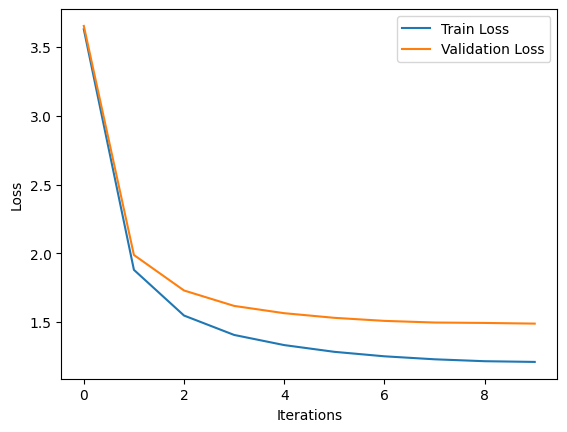

In [13]:
# Plot training and validation loss
plt.plot(loss_history["train"], label="Train Loss")
plt.plot(loss_history["val"], label="Validation Loss")

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.legend()
plt.show()

### Model saving

In [14]:
# Save model checkpoint
checkpoint = {
    "data": data,

    "model_state_dict": model.state_dict(),

    "hyperparameters": {
        "vocab_size": vocab_size,
        "emb_d": emb_d,
        "block_size": block_size,
        "num_heads": num_heads,
        "num_layers": num_layers,
        "dropout": dropout
    },

    "input_mapper": input_mapper,
    "output_mapper": output_mapper
}

torch.save(checkpoint, "shakespeare_gpt.pth")